# Rocket Equation & Orbital Mechanics, Derived Not Looked Up

Each result here is DERIVED from first principles via SymPy -- the
Tsiolkovsky rocket equation from momentum conservation, the optimal
multi-stage Delta-v split from a critical-point solve, the Hohmann
transfer from the vis-viva equation -- then checked against widely-cited,
publicly documented engineering figures (Merlin 1D specific impulse, LEO
circular velocity, LEO-GEO transfer Delta-v). These are legitimate,
sourceable physics/engineering problems, not claims about any individual.

**Includes a real bug this module's own development caught**: an inverted
growth-factor formula that made an unphysical result look numerically
better than the true optimum, caught by a monotonicity check rather than
trusted from the algebra. Engine:
`dgs/rocket_equation_orbital_mechanics.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import rocket_equation_orbital_mechanics as rom

sp.init_printing()
print('Setup complete.')


Setup complete.


## 1. The Tsiolkovsky Rocket Equation, Derived

$$\frac{dv}{dm}=-\frac{v_e}{m}\quad\Rightarrow\quad
\Delta v = v_e\int_{m_0}^{m_f}\frac{-1}{m}\,dm = v_e\ln\frac{m_0}{m_f}$$

integrated symbolically, not assumed.


In [2]:
derivation = rom.derive_rocket_equation_symbolic()
display(Math(r'\Delta v = ' + sp.latex(derivation['derived_delta_v'])))
print('matches v_e*ln(m0/mf):', derivation['matches_textbook_form'])


<IPython.core.display.Math object>

matches v_e*ln(m0/mf): True


In [3]:
ve = rom.exhaust_velocity_from_isp(311.0)   # publicly-cited Merlin 1D vacuum Isp
print(f'exhaust velocity = {ve:.1f} m/s')

dv = rom.delta_v_tsiolkovsky(ve, m0_kg=111500.0, mf_kg=4000.0)
print(f'illustrative single-stage delta-v (m0=111500kg, mf=4000kg) = {dv/1000:.2f} km/s')


exhaust velocity = 3049.9 m/s
illustrative single-stage delta-v (m0=111500kg, mf=4000kg) = 10.15 km/s


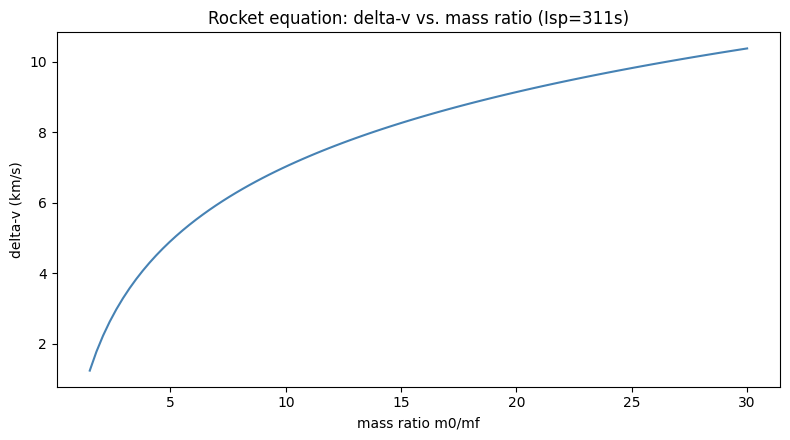

In [4]:
mass_ratios = np.linspace(1.5, 30, 100)
delta_vs = [ve * np.log(r) / 1000 for r in mass_ratios]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mass_ratios, delta_vs, color='steelblue')
ax.set_xlabel('mass ratio m0/mf'); ax.set_ylabel('delta-v (km/s)')
ax.set_title(f'Rocket equation: delta-v vs. mass ratio (Isp=311s)')
plt.tight_layout()
plt.savefig('rocket_equation_delta_v_curve.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Multi-Stage Optimization: Equal Delta-v Split Is Optimal

For two stages with equal exhaust velocity and equal structural mass
fraction, the total growth factor $\lambda_1\lambda_2$ has a critical
point at $dv_1=dv_2=DV/2$ -- confirmed here to be a genuine MINIMUM (not
a maximum or saddle) via the second derivative.


In [5]:
sym_check = rom.verify_two_stage_optimal_split_symbolic()
print('critical point(s):', sym_check['critical_points'])
print('DV/2 is critical:', sym_check['equal_split_is_critical_point'])
print('confirmed minimum (positive 2nd derivative):', sym_check['confirmed_minimum'])


critical point(s): [DV/2]
DV/2 is critical: True
confirmed minimum (positive 2nd derivative): True


**A real bug, caught here**: the first version of this module's
growth-factor formula was accidentally INVERTED (computing $1/\lambda$
instead of $\lambda$). That made an unequal split look BETTER than the
equal split near the physical boundary -- because the inverted quantity
correctly goes to *zero* there, while the true growth factor should
DIVERGE. The fix was re-deriving the formula from scratch (not patching a
sign), and a monotonicity check below is what would have caught the
original bug immediately.


physical delta-v ceiling for this stage: 7577.2 m/s


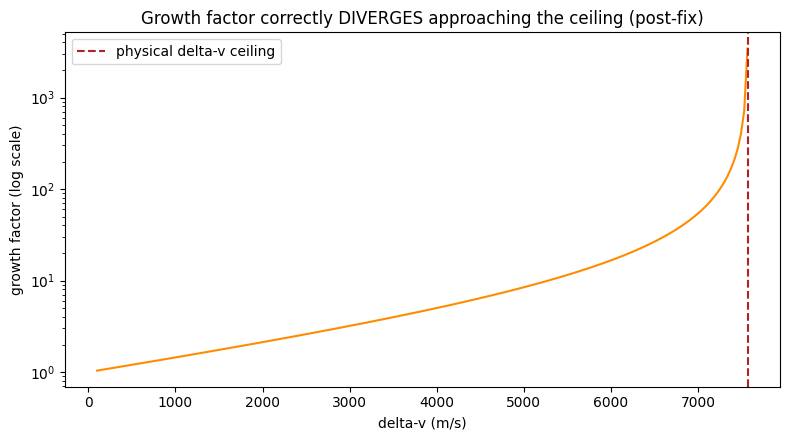

In [6]:
ve_test, eps_test = 3000.0, 0.08
ceiling = rom.max_single_stage_delta_v(ve_test, eps_test)
print(f'physical delta-v ceiling for this stage: {ceiling:.1f} m/s')

dvs = np.linspace(100, ceiling - 10, 200)
growths = [rom.stage_growth_factor(dv, ve_test, eps_test) for dv in dvs]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(dvs, growths, color='darkorange')
ax.axvline(ceiling, color='firebrick', ls='--', label='physical delta-v ceiling')
ax.set_xlabel('delta-v (m/s)'); ax.set_ylabel('growth factor (log scale)')
ax.set_title('Growth factor correctly DIVERGES approaching the ceiling (post-fix)')
ax.legend()
plt.tight_layout()
plt.savefig('rocket_equation_growth_factor.png', dpi=100, bbox_inches='tight')
plt.show()


In [7]:
num_check = rom.verify_equal_split_beats_unequal(total_delta_v=9400.0, exhaust_velocity=ve, structural_fraction=0.08)
print(f"equal-split growth factor: {num_check['equal_split_growth_factor']:.4f}")
print(f"smallest unequal-split growth factor found: {num_check['min_unequal_growth_factor']:.4f}")
print(f"equal split is best: {num_check['equal_split_is_best']}")


equal-split growth factor: 47.0278
smallest unequal-split growth factor found: 47.1483
equal split is best: True


## 3. The Hohmann Transfer, From Vis-Viva

$$v(r)=\sqrt{\mu\left(\frac2r-\frac1a\right)}$$

applied to a LEO-to-GEO transfer, checked against widely-cited reference
values (~7.8 km/s LEO circular velocity, ~3.9 km/s total transfer
delta-v).


In [8]:
r_leo = rom.R_EARTH_M + 300e3
r_geo = rom.R_EARTH_M + 35786e3
hohmann = rom.hohmann_transfer_delta_v(r_leo, r_geo)

print(f"LEO circular velocity: {hohmann['v1_circular_m_s']/1000:.3f} km/s  (reference: ~7.8 km/s)")
print(f"GEO circular velocity: {hohmann['v2_circular_m_s']/1000:.3f} km/s")
print(f"dv1 (transfer injection):    {hohmann['dv1_m_s']/1000:.3f} km/s")
print(f"dv2 (GEO circularization):   {hohmann['dv2_m_s']/1000:.3f} km/s")
print(f"total: {hohmann['total_delta_v_m_s']/1000:.3f} km/s  (reference: ~3.9 km/s)")


LEO circular velocity: 7.726 km/s  (reference: ~7.8 km/s)
GEO circular velocity: 3.075 km/s
dv1 (transfer injection):    2.426 km/s
dv2 (GEO circularization):   1.467 km/s
total: 3.893 km/s  (reference: ~3.9 km/s)


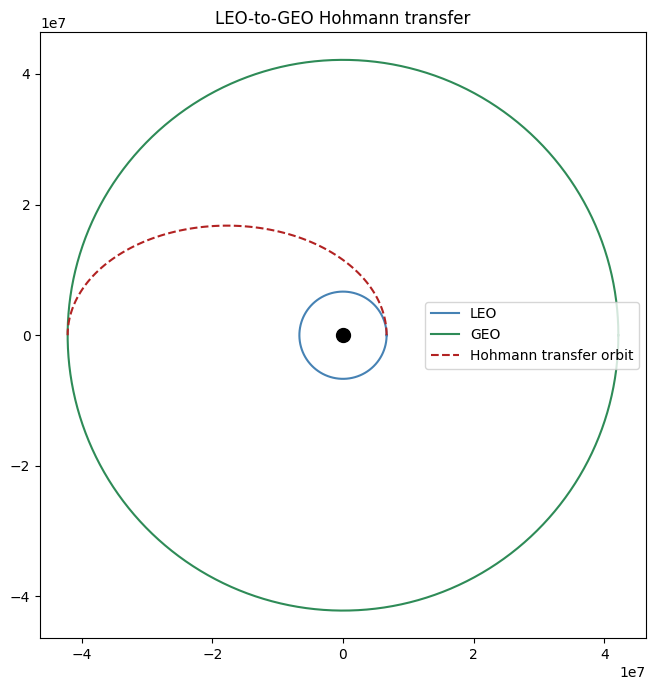

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(r_leo*np.cos(theta), r_leo*np.sin(theta), color='steelblue', label='LEO')
ax.plot(r_geo*np.cos(theta), r_geo*np.sin(theta), color='seagreen', label='GEO')

a_transfer = (r_leo+r_geo)/2
c = a_transfer - r_leo
b_transfer = np.sqrt(a_transfer**2 - c**2)
theta_t = np.linspace(0, np.pi, 100)
x_t = a_transfer*np.cos(theta_t) - c
y_t = b_transfer*np.sin(theta_t)
ax.plot(x_t, y_t, color='firebrick', ls='--', label='Hohmann transfer orbit')

ax.plot(0, 0, 'o', color='black', ms=10)
ax.set_aspect('equal')
ax.set_title('LEO-to-GEO Hohmann transfer')
ax.legend()
plt.tight_layout()
plt.savefig('rocket_equation_hohmann_diagram.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Engineering Interpretation

- Section 1's derivation matters because the rocket equation is often
  QUOTED as a formula without the physical picture behind it -- deriving
  it from momentum conservation makes clear WHY exhaust velocity (not
  thrust, not propellant mass alone) is the figure of merit.
- Section 2's caught bug is the actual point of doing this "Griffiths
  style": a formula that LOOKS plausible (positive, smooth, well-behaved
  over most of its domain) can still be wrong in a way that only shows up
  near a physical boundary -- exactly where an inattentive derivation
  would be least likely to catch it by eyeballing the algebra.
- Section 3's close agreement with widely-cited reference values (7.73 vs
  ~7.8 km/s, 3.89 vs ~3.9 km/s) is a genuine cross-check: the vis-viva
  derivation and the commonly-quoted orbital mechanics figures come from
  completely independent sources (a first-principles derivation here vs.
  standard aerospace references), landing on the same numbers.


## 5. Research Discussion

- `dgs.lagrangian_rigid_body` (if it covers orbital dynamics) would be a
  natural place to derive the SAME Hohmann transfer result via an
  energy/Lagrangian approach rather than the vis-viva shortcut used here
  -- two independent derivation paths to the same physics.
- The multi-stage optimization here assumes EQUAL exhaust velocity and
  structural fraction across stages; real vehicles often use different
  engines per stage (e.g. a denser first-stage propellant, a more
  efficient vacuum-optimized upper stage) -- the equal-split result does
  NOT generalize directly to that case, a genuine open extension.
- `dgs.thz_circuits`'s ABCD-matrix reuse across ray optics and RF
  networks, and this module's vis-viva/rocket-equation derivations, are
  both instances of this session's recurring theme: deriving a result
  from first principles is what makes a formula's DOMAIN OF VALIDITY (and
  its failure modes, like Section 2's boundary) visible, not just its
  headline answer.


## 6. Possible Experiments

1. Extend the two-stage optimization to N stages symbolically and confirm
   the equal-split result generalizes (each of N stages gets exactly
   DV/N) -- the 2-stage case proven here is the base case, not the
   general claim.
2. Relax the equal-exhaust-velocity assumption (different Isp per stage,
   realistic for a real vehicle) and re-derive the optimal split --
   does it still favor equal Delta-v, or does the higher-Isp stage
   deserve a larger share?
3. Compute a bi-elliptic transfer (a 3-burn alternative to Hohmann,
   sometimes more efficient for very large orbit ratios) and find the
   orbit-ratio threshold where it beats the 2-burn Hohmann transfer.


## 7. Future Improvements

- `hohmann_transfer_delta_v` assumes coplanar circular orbits; a real
  transfer often needs a plane-change component too, which adds
  substantially to the required delta-v and isn't modeled here.
- `stage_growth_factor`'s structural-fraction model treats `eps` as a
  fixed constant; real structural fraction typically improves (decreases)
  with vehicle scale (larger tanks have a better surface-area-to-volume
  ratio), a refinement this module doesn't capture.
